# **Timeseries Analysis**

Time series is a sequence of data from a natural or social process (or a trial) **observed over time**: it is **time-ordered** which means we must not interchange the positions of any two values of time series.

There are many time series examples in our everyday life:
- one's body weight measured on every Sunday
- daily closing price of a listed stock
- daily minimum temperature of İstanbul

The first step of time series analysis is to plot the time series data:
- the index of time t on the x-axis
- the observed value on the y-axis

Below are some time series examples:

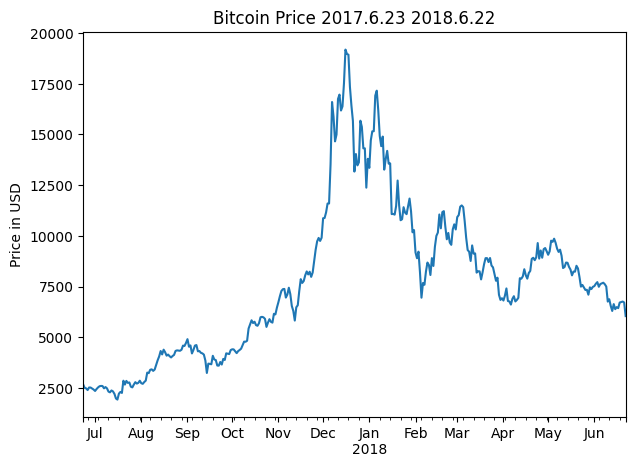

In [1]:
## Bitcoin example: price time series from 23 June 2017 to 22 June 2018
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = [7, 5]

bitcoin = pd.read_excel('./data/BitcoinPrice17-6-23-18-6-22.xlsx', header = 0)
dat = pd.date_range('2017 06 23', periods = len(bitcoin), freq = 'D')
bitcoin.index = dat
price = bitcoin['ClosingP']
price.plot(); plt.title('Bitcoin Price 2017.6.23 2018.6.22')
plt.ylabel('Price in USD');
plt.show()

**We can observe that the Bitcoin price**
- dramatically increases from October 2017,
- reaches the peak at the end of 2017,
- peaks at 19,187 USD reached in December 16, 2017,
- since then it fluctuantly decreases.

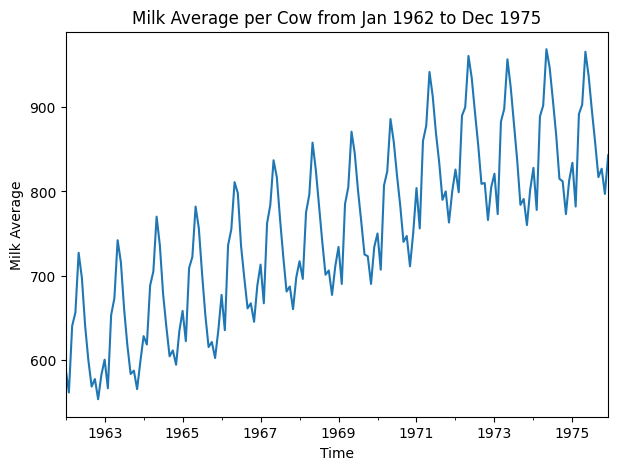

In [2]:
## Monthly average milk per cow from January 1962 to December 1975
milk = pd.read_excel('./data/milk.xlsx', header = None)

mseries = pd.concat([milk.loc[0], milk.loc[1], milk.loc[2],
                     milk.loc[3], milk.loc[4], milk.loc[5], milk.loc[6],
                     milk.loc[7], milk.loc[8], milk.loc[9], milk.loc[10],
                     milk.loc[11], milk.loc[12], milk.loc[13], milk.loc[14],
                     milk.loc[15], milk.loc[16]], ignore_index = 'true')

mts = mseries.drop([168, 169])

timeindex = pd.date_range('1962 01', periods = 168, freq = 'ME')
mts.index = timeindex

mts.plot()
plt.title('Milk Average per Cow from Jan 1962 to Dec 1975')
plt.xlabel('Time'); plt.ylabel('Milk Average');
plt.show()

**We can observed that**
- the time series possesses a linear ascending trend, and so we say that this time series has a **deterministic increasing trend (component)**;
- at the same time, we also see that the time series has a period of 12 months, and thus we say that this time series possesses **deterministic seasonality (component)**;
- besides, the milk production is high at the middle of year and low at the beginning and end of year.

**In these examples**
- a time series is a sequence of data in time order;
- the time series value is influenced by a lot of random factors;
- the time series value at time t cannot be obtained before time t arrives, hence the time series value at time t is random.

**Notation:** Let $X_t$ denote the time series variable at time t. That is to say, the value we obtain when time t arrives is a realization (or sample or observation) of the random variable $X_t$, and it can be denoted by $x_t$.

**Definition:** An ordered sequence of random variables $\{X_t\}$ is called a time series where $t$ is time index and $t \in T = \{\ldots, −n, \ldots , −1, 0, 1, \ldots , n, \ldots\}$. The time series values which have been recorded are called a realization (or sample or observation) of the time series.

A realization (or sample) of the time series can also be simply called a time series and often denoted by $\{x_{1:n}\} = \{x_t ; t = 1, 2, · · · , n\}$. Please note that we sometimes use $\{a:b\}$ to represent $\{a, a + 1, \ldots , b\}$ for any integers $a \leq b$ and $x_{1:n} = \{x_{1:n}\}$ to represent $\{x_1, x_2, \ldots , x_n\} = \{x_t ; t = 1, 2, \ldots , n\}$.

## **Auto Correlation Functions**

**Autocorrelation** measures how much a signal or time series is related to a **delayed version of itself**.

In simple terms:
- It tells you **whether past values influence future values**
- It helps you see **patterns, trends, or repeating cycles** in data

Example question autocorrelation answers:
> “If the value is high today, is it likely to be high tomorrow?”

The **Autocorrelation Function (ACF)** calculates autocorrelation for **different time delays**, called **lags**.

- **Lag 0** → correlation of the series with itself (always **1**)
- **Lag 1** → correlation between today and yesterday
- **Lag 2** → correlation between today and two days ago
- And so on...

The ACF shows how correlation **changes as the lag increases**.

ACF helps you:
- Detect **patterns** in time series data
- Identify **seasonality** (repeating cycles)
- Decide how many past values matter
- Build and evaluate **time series models** (like ARIMA)

**Interpreting ACF Values**

ACF values range from **-1 to 1**:

- **1** → perfect positive correlation
- **0** → no correlation
- **-1** → perfect negative correlation

**What different patterns mean:**

- **Slow decay** → strong trend in the data
- **Sharp drop to zero** → little dependence on past values
- **Repeating peaks** → seasonal behavior

/var/folders/x6/84z8516j6vz779pfs_wg_z140000gn/T/ipykernel_38603/3486391185.py:8: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  dates = pd.date_range(start='1992', periods = len(x), freq='Q')


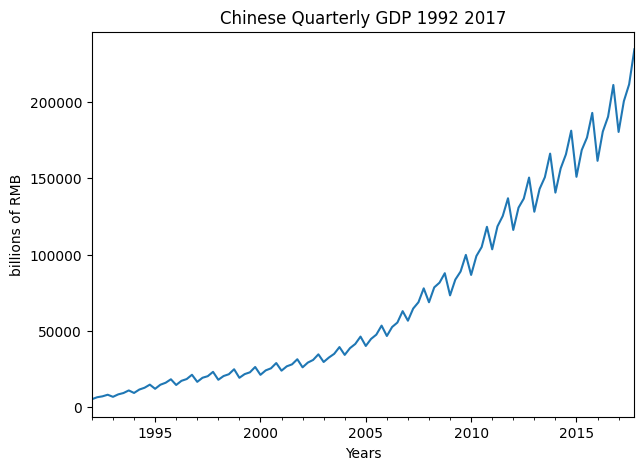

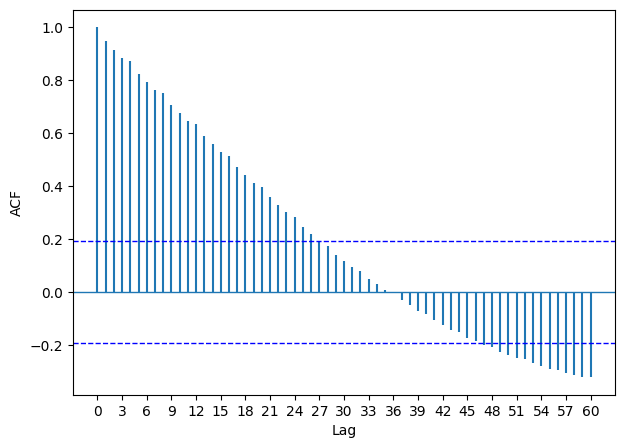

In [3]:
# Chineese quarterly GDP example = 1992.1 to 2017.4

import pandas as pd
import matplotlib.pyplot as plt
from PythonTsa.plot_acf_pacf import acf_pacf_fig

x = pd.read_csv('./data/gdpquarterlychina1992.1-2017.4.txt')
dates = pd.date_range(start='1992', periods = len(x), freq='Q')
x.index = dates
x.plot(legend = None); plt.title('Chinese Quarterly GDP 1992 2017');
plt.ylabel('billions of RMB'); plt.xlabel('Years');
plt.show()

acf_pacf_fig(x, both = False, lag = 60)
plt.show()

The time series plot of the Chinese quarterly GDP clearly shows an **increasing trend** and **seasonal effects**, and so this time series is **nonstationary**. Its correlogram (ACF plot) indicates that the ACF values very slowly fall into the 95% confidence (interval) band and then continue to fall out of the confidence band.

## **White Noise**

**White noise**
It is the building block in time series analysis and vitally important.

**Definition:** A time series $\{W_t\}$ is **white noise** or **purely random** if
- for all $t$, $E(W_t) = \mu$
- for all $t$, $Var(W_t) = \sigma^2$
- when $s \neq t$, $Cov(W_s, W_t) = 0$ (i.e. uncorrelated at different time points)

In simple terms:
- Each value is **independent** of the others  
- Knowing the past tells you **nothing about the future**

Example idea:
> Yesterday’s value gives no clue about today’s value.

**Key Properties of White Noise**

A time series is considered white noise if it has these properties:

1. **Zero Mean**
   - The values fluctuate around zero (or a constant mean)

2. **Constant Variance**
   - The spread of the values stays the same over time

3. **No Autocorrelation**
   - There is **no relationship** between values at different times

**White Noise and Autocorrelation**

For white noise:
- **Lag 0** autocorrelation = 1 (by definition)
- **All other lags** ≈ 0

In an ACF plot:
- Bars after lag 0 stay **within the confidence bands**
- No clear pattern or decay appears

This means the series has **no memory**.

**How White Noise Looks in Practice**

White noise typically:
- Jumps up and down randomly
- Shows no trend
- Shows no seasonality
- Shows no repeating patterns

Each observation is just random variation.

**Why Is White Noise Important?**

White noise is important because:
- It represents **pure randomness**
- A good time series model should leave **white noise residuals**


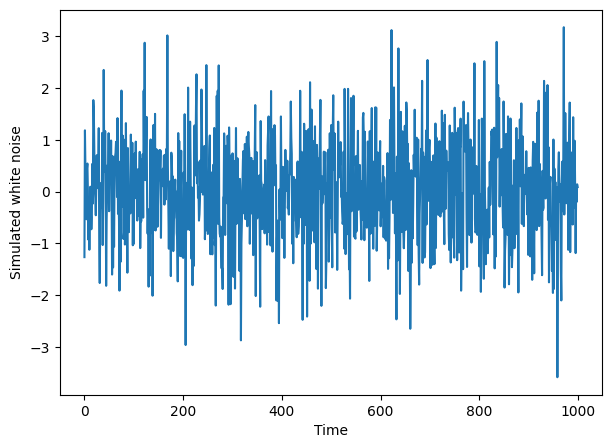

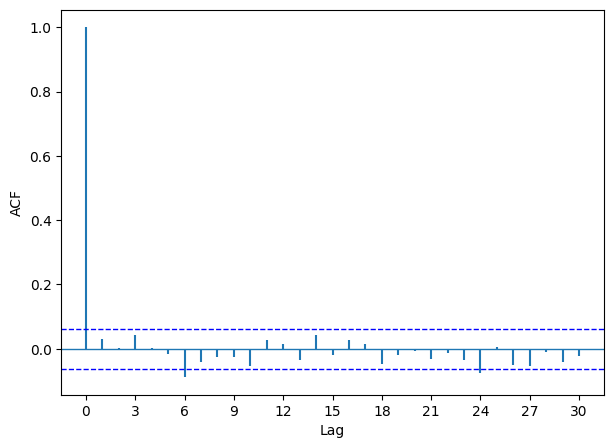

In [4]:
#Simulation example for WN
from numpy import random
import pandas as pd
import matplotlib.pyplot as plt
from PythonTsa.plot_acf_pacf import acf_pacf_fig
random.seed(135) # for repeat
x = random.normal(loc = 0, scale = 1, size = 1000)
xts = pd.Series(x)
xts.plot(); plt.xlabel('Time')
plt.ylabel('Simulated white noise')
plt.show()

acf_pacf_fig(xts, both=False, lag=30)
plt.show()

The time series plot of the simulated Gaussian white noise indicates that it always fluctuates around the horizontal line y = 0. Its correlogram displays the characteristics of a white noise’s autocorrelation function, namely, $\rho(k) = 0$ for all $k \neq 0$. Thus, there is an  intuitive method for testing that a stationary time series is a white noise or not: to examine its ACF plot.

## **Random Walk**

**Random Walk**

Another interesting and useful time series model is the random walk. Random walks have applications to many scientific fields including ecology, psychology, computer science, physics, biology, as well as economics. For example, random walks are used to depict a molecule’s behavior path in a liquid or a gas in physics and the price movement of a stock in financial market in economics.

**Definition:** $\{X_t\}$ is called random walk if $X_t = X_{t-1} + W_t$ where $W_t$ is white noise and $X_{t-1}$ and $W_t$ are uncorrelated.

It can easily be seen that $X_t = X_{t-1} + W_t = X_{t-2} + W_{t-1} + W_t = \ldots =  X_{0} + W_{1} + W_2 + \ldots + W_{t-1}+W_{t}$. If $E(W_t) = 0$, then $E(X_t) = X_0$, i.e. mean-stationary. However, it is not variance-stationary, since $Var(X_t) = Var(X_0) + t \sigma^2$, where $Var(W_t)= \sigma^2$.

Thus it can be seen that the random walk is not variance stationary. Naturally, it is more unlikely to be stationary. Therefore the random walk is a non-stationary time series that has neither deterministic trend nor deterministic seasonality.

**random walk** is a process where the **current value depends on the previous value plus a random change**.

In simple terms:
> Each step moves forward by adding some randomness, and there is **no predictable direction**.

**A Simple Example:**

Imagine you start at **0**.

- At each time step:
  - You flip a coin or draw a random number
  - You **add** that number to your current position

**Key Characteristics of a Random Walk**

1. No Memory Beyond the Last Value
The best prediction of tomorrow’s value is **today’s value**.

\[
E(y_t | y_{t-1}) = y_{t-1}
\]

2. Non-Stationary
A random walk is **non-stationary**:
- Mean changes over time
- Variance increases as time goes on

This makes many standard time series models invalid unless the data is transformed.

3. Shocks Are Permanent
If a big random shock happens, its effect **never disappears**.

Example:
- A sudden jump today affects all future values

**Random Walk with Drift**

Sometimes a random walk has a **trend** (called drift):

\[
y_t = y_{t-1} + c + \varepsilon_t
\]

Where:
- \(c\) = constant drift term

This creates a **general upward or downward movement** over time.

**Why Is Random Walk Important?**

Random walks are important because:
- Many **financial time series** (e.g., stock prices) behave like random walks
- They explain why **predicting prices is so hard**
- They motivate techniques like **differencing** to achieve stationarity


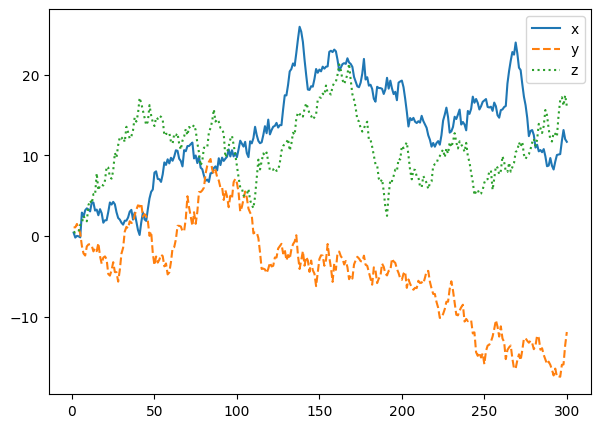

In [5]:
# Random walk simulation example
import numpy as np
import pandas as pd
from numpy.random import normal
import matplotlib.pyplot as plt
np.random.seed(1357)

a = normal(size = 300); b = normal(size = 300); c = normal(size = 300)
x = np.cumsum(a); y = np.cumsum(b); z = np.cumsum(c)
xyz = pd.DataFrame({'x': x, 'y': y, 'z': z})
xyz.index = range(1,301)
xyz.plot(style = ['-', '--', ':'])
plt.show()

## **Seasonality Decomposition**

**Seasonality decomposition** is a way to **break a time series into simpler parts** so we can better understand how it behaves.

Instead of looking at one complicated series, we split it into:

1. **Trend**
2. **Seasonality**
3. **Residual (Noise)**

This helps answer questions like:
- Is the series generally going up or down?
- Does it repeat patterns (daily, monthly, yearly)?
- What part is just random noise?

1. Trend (T)
The **trend** shows the **long-term movement** of the data.

Examples:
- Sales slowly increasing over years
- Website traffic gradually declining

Think of it as the **overall direction**.

2. Seasonality (S)
The **seasonal component** captures **regular, repeating patterns**.

Examples:
- Higher sales every December
- More electricity usage every summer
- Weekly traffic peaks on Mondays

Seasonality is **predictable and repeats at fixed intervals**.

3. Residual / Noise (R)
The **residual** is what’s left after removing trend and seasonality.

It represents:
- Random fluctuations
- Unexpected events
- Measurement errors

Ideally, this part looks like **random noise**.


**Australian Total Employed Persons:** The time series of Australian monthly total employed persons from February 1978 to November 2018 (in thousands)


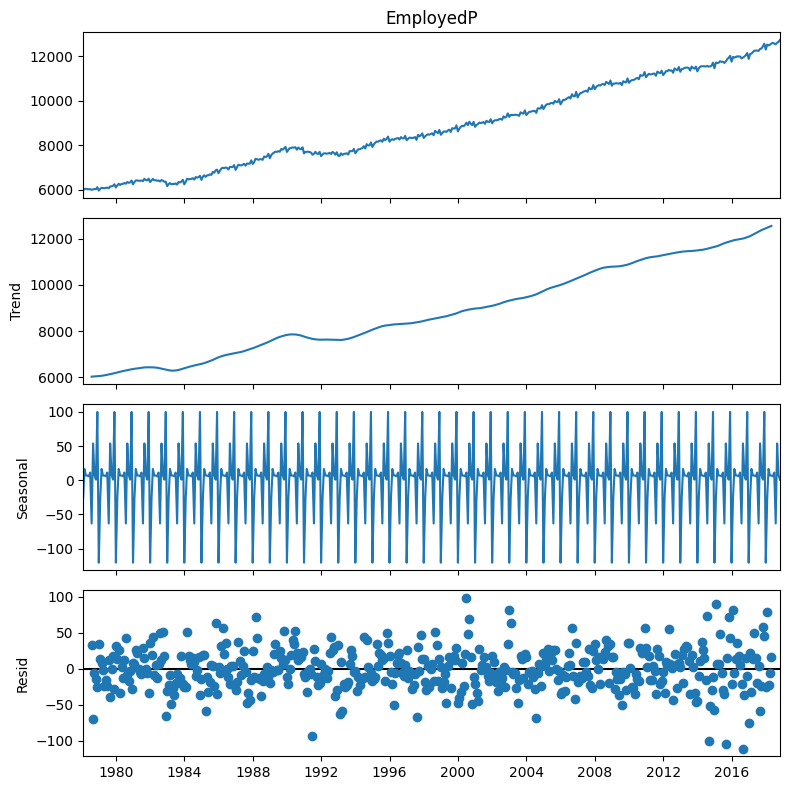

In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose

aul = pd.read_excel('./data/AustraliaEmployedTotalPersons.xlsx', header = 0)
timeindex = pd.date_range('1978-02', periods = len(aul), freq = 'MS')
aul.index = timeindex
aults = aul['EmployedP']

plt.rcParams['figure.figsize'] = 8, 8
aultsdeca = seasonal_decompose(aults, model = 'additive')
aultsdeca.plot();
plt.show()

This decomposition splits the employment time series into **Trend**, **Seasonal**, and **Residual** components to better understand its behavior.

**Original Series**
- Shows a **strong long-term increase** in total employment.
- Short-term ups and downs are visible around the long-run path.

**Trend**
- The trend component shows **steady growth in employment** over the entire period.
- Brief slowdowns or flattening appear during economic downturns, but the overall direction remains upward.
- This reflects long-term population growth and economic expansion in Australia.

**Seasonal**
- A **clear and stable monthly seasonal pattern** is present.
- Employment rises and falls at similar times each year, likely due to:
  - Hiring cycles
  - Holidays
  - Industry seasonality
- The seasonal effect is relatively small compared to the trend.

**Residual (Irregular)**
- Residuals are centered around zero with **no clear pattern**.
- Most unexplained variation is random.
- Occasional large spikes may correspond to unusual economic events or shocks.

> Australian employment is driven mainly by a strong upward trend, with predictable seasonal fluctuations and relatively small random noise.


## **SARIMA**

**SARIMA** stands for **Seasonal AutoRegressive Integrated Moving Average**.

It is a time series model used when data shows:
- A **trend**
- **Seasonality**
- Dependence on past values and past errors

SARIMA extends the ARIMA model by **explicitly modeling seasonal patterns**.

**Why Do We Need SARIMA?**

Some time series:
- Repeat patterns every month, quarter, or year
- Cannot be modeled well with ARIMA alone

SARIMA handles this by adding **seasonal terms**.

Common examples:
- Monthly sales
- Electricity demand
- Employment data
- Website traffic

**SARIMA Model Notation**

A SARIMA model is written as:

\[
\text{SARIMA}(p, d, q)(P, D, Q)_s
\]

Where:

**Non-Seasonal Part**
- **p**: Number of autoregressive (AR) terms  
- **d**: Number of differences (to remove trend)  
- **q**: Number of moving average (MA) terms  

**Seasonal Part**
- **P**: Seasonal AR terms  
- **D**: Seasonal differencing  
- **Q**: Seasonal MA terms  
- **s**: Length of the season (e.g. 12 for monthly data)

**Intuition Behind Each Part**

1. Autoregressive (AR)
- Uses **past values** to predict the current value

2. Moving Average (MA)
- Uses **past forecast errors** to adjust predictions

3. Differencing (I)
- Removes trend and seasonality to make the series stationary

**Example (Monthly Data)**

For monthly data with yearly seasonality:

\[
\text{SARIMA}(1,1,1)(1,1,1)_{12}
\]

This means:
- Use last month’s value and error
- Remove trend with one difference
- Remove yearly seasonality with seasonal differencing
- Model seasonal dependence from the same month last year

**How SARIMA Works (Conceptually)**

1. Remove trend and seasonality using differencing
2. Model relationships in the cleaned series
3. Use those patterns to forecast future values
4. Add trend and seasonality back to get final forecasts

**Strengths of SARIMA**

- Handles **trend + seasonality**
- Works well for **short- to medium-term forecasts**
- Interpretable and statistically grounded

**Limitations of SARIMA**

- Requires careful parameter tuning
- Assumes linear relationships
- Not ideal for very complex or highly nonlinear patterns

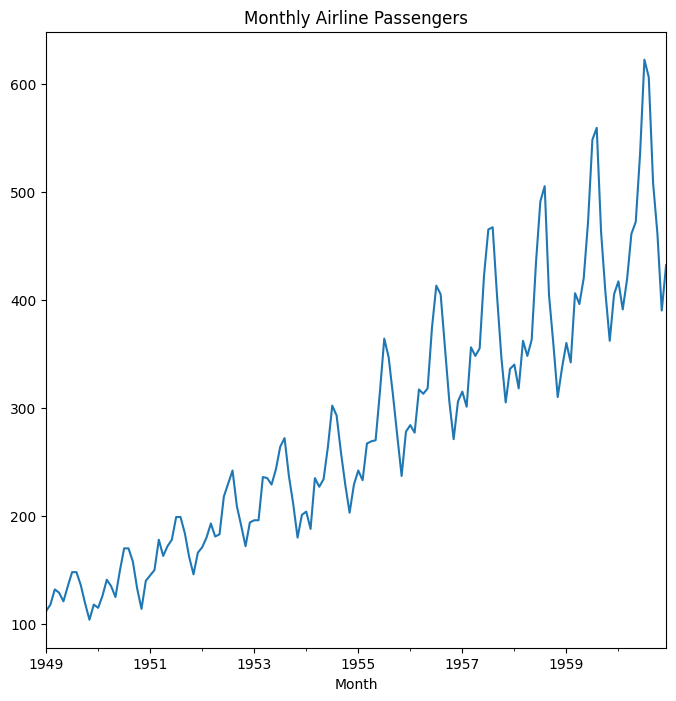

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

data = pd.read_csv("./data/airline-passengers.csv")

# Rename columns for convenience
data.columns = ["Month", "Passengers"]

# Convert Month to datetime and set index
data["Month"] = pd.to_datetime(data["Month"])
y = data.set_index("Month")["Passengers"].asfreq("MS")

y.plot(title="Monthly Airline Passengers")
plt.show()


In [8]:
train = y.iloc[:-24]
test = y.iloc[-24:]

In [9]:
model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(disp=False)
print(results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                         Passengers   No. Observations:                  120
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -348.860
Date:                            Mon, 29 Dec 2025   AIC                            707.720
Time:                                    17:40:58   BIC                            720.383
Sample:                                01-01-1949   HQIC                           712.833
                                     - 12-01-1958                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4557      0.436     -1.044      0.296      -1.311       0.400
ma.L1          0.2194      0.458   

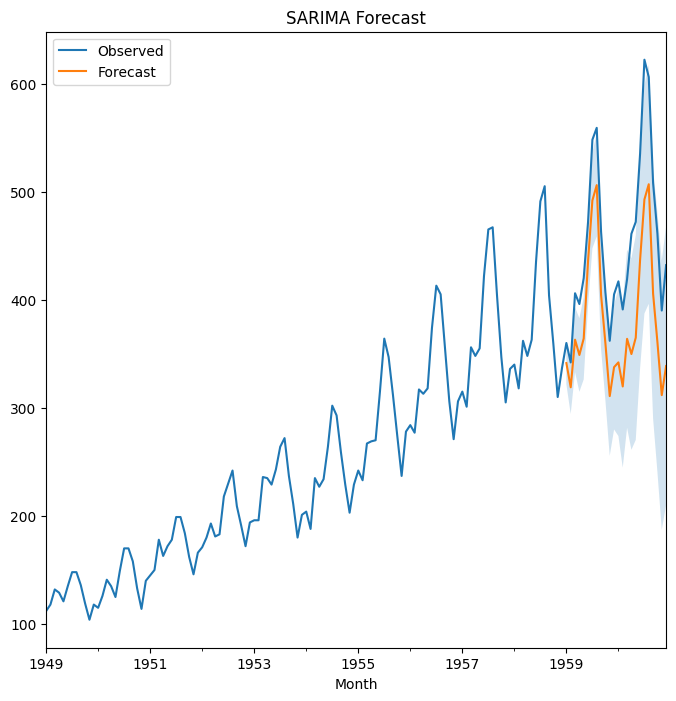

In [10]:
forecast_res = results.get_forecast(steps=len(test))
forecast = forecast_res.predicted_mean
conf_int = forecast_res.conf_int()

ax = y.plot(label="Observed", title="SARIMA Forecast")
forecast.plot(ax=ax, label="Forecast")

ax.fill_between(
    conf_int.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    alpha=0.2
)

plt.legend()
plt.show()


In [11]:
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE : 69.90
RMSE: 75.63


## **Facebook's Propeth**

**Prophet** is a time series forecasting library developed by **Facebook (now Meta)**.

It is designed to:
- Be **easy to use**
- Work well with **real-world business data**
- Automatically handle **trend, seasonality, and holidays**

Prophet is especially useful when your data:
- Has strong seasonal patterns
- Contains missing values
- Has outliers or sudden changes

Prophet models a time series as a **sum of components**:

\[
y(t) = g(t) + s(t) + h(t) + \varepsilon(t)
\]

Where:
- \(g(t)\): **Trend** (long-term growth or decline)
- \(s(t)\): **Seasonality** (weekly, yearly, etc.)
- \(h(t)\): **Holidays / events**
- \(\varepsilon(t)\): **Noise**

1. Trend Component

Prophet models trend using:
- **Piecewise linear growth**, or
- **Logistic growth** (with a maximum capacity)

It can automatically detect **changepoints**, where the trend changes direction or speed.

2. Seasonality Component

Prophet handles seasonality using **Fourier series**.

Built-in support for:
- Yearly seasonality
- Weekly seasonality
- Daily seasonality

Seasonality is:
- Smooth
- Repeating
- Interpretable

3. Holiday & Event Effects

You can explicitly add:
- Public holidays
- Promotions
- Special events

These effects:
- Occur on specific dates
- Can have impacts before and after the event

Prophet is popular because it:
- Requires **very little tuning**
- Is robust to missing data
- Handles outliers well
- Produces **interpretable components**
- Works well for business forecasting

**Prophet vs ARIMA / SARIMA**

| Feature | Prophet | SARIMA |
|------|--------|--------|
| Trend changes | Automatic | Manual |
| Seasonality | Built-in | Manual |
| Missing data | Handles well | Needs preprocessing |
| Interpretability | High | Moderate |
| Ease of use | Very easy | More complex |

**When Prophet Works Best**

- Medium to large datasets
- Strong seasonal patterns
- Clear trend behavior
- Business and operational data

Examples:
- Sales
- Website traffic
- Demand forecasting
- Employment or economic indicators


/Users/ozgunyargi/SU/DSA210/Recitations/Recitation13/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


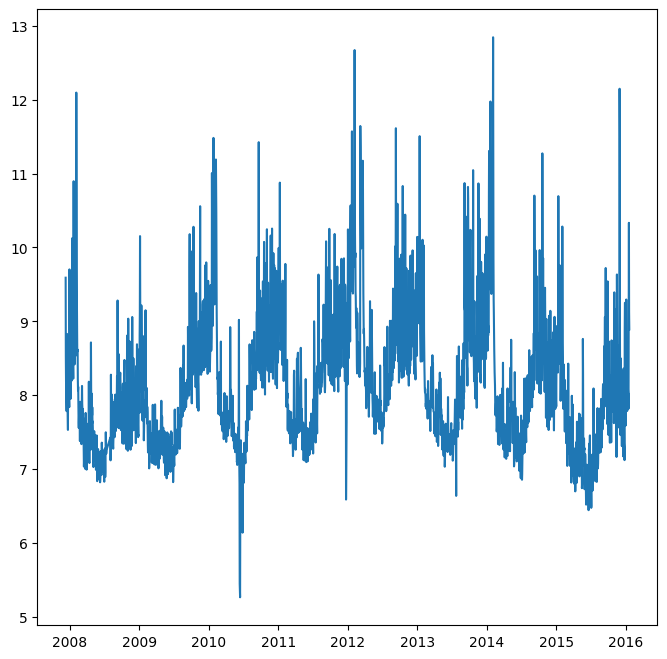

In [12]:
import pandas as pd
from prophet import Prophet
df = pd.read_csv('./data/example_wp_log_peyton_manning.csv')
df['ds'] = pd.to_datetime(df['ds'])

plt.plot(df.ds, df.y)
plt.show()

In [13]:
m = Prophet(
    changepoints=None,
    # If None, Prophet automatically selects potential changepoints
    # Changepoints are locations where the trend is allowed to change

    n_changepoints=25,
    # Maximum number of changepoints to consider in the trend
    # More changepoints → more flexible trend
    # Fewer changepoints → smoother trend

    yearly_seasonality="auto",
    # Detect and model yearly seasonality automatically
    # Can also be set to:
    #   True  → force yearly seasonality
    #   False → disable yearly seasonality
    #   int   → number of Fourier terms (controls complexity)

    weekly_seasonality="auto",
    # Automatically detect weekly seasonality
    # Useful for data with weekly patterns (e.g., website traffic)

    daily_seasonality="auto"
    # Automatically detect daily seasonality
    # Typically used for high-frequency data (hourly or sub-daily)
)
m.fit(df)

17:40:58 - cmdstanpy - INFO - Chain [1] start processing
17:40:59 - cmdstanpy - INFO - Chain [1] done processing


In [14]:
# Create a future dataframe extending 365 days beyond the last observation
# Prophet automatically keeps the same frequency as the training data
future = m.make_future_dataframe(periods = 365)

# Generate forecasts for both historical and future dates
forecast = m.predict(future)

forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
3265,2017-01-15,8.208400,7.492737,8.910886
3266,2017-01-16,8.533418,7.767430,9.190133
3267,2017-01-17,8.320838,7.534905,9.002737
3268,2017-01-18,8.153458,7.421716,8.858851
3269,2017-01-19,8.165398,7.475407,8.844575


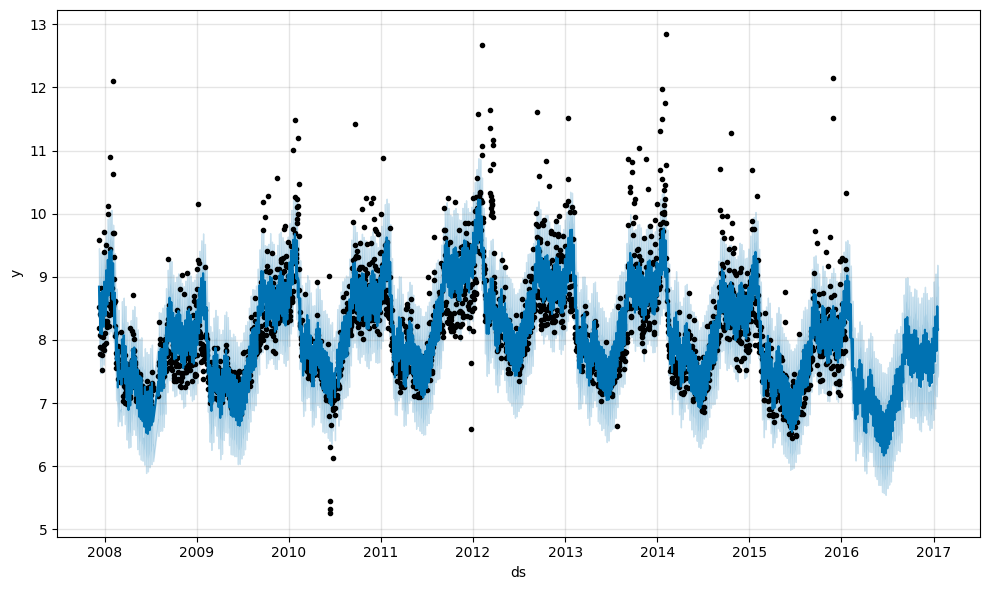

In [15]:
fig1 = m.plot(forecast)